In [1]:
# Install required packages (run once)
!pip install ultralytics opencv-python-headless matplotlib pandas seaborn -q

# Verify installation
print("\n" + "="*60)
print("Verifying package installations...")
print("="*60)

import numpy as np
print(f"✓ NumPy version: {np.__version__}")

import torch
print(f"✓ PyTorch version: {torch.__version__}")
print(f"✓ CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"✓ GPU: {torch.cuda.get_device_name(0)}")

import ultralytics
print(f"✓ Ultralytics version: {ultralytics.__version__}")

import cv2
print(f"✓ OpenCV version: {cv2.__version__}")

print("="*60)
print("All packages installed successfully!")
print("="*60)


Verifying package installations...
✓ NumPy version: 2.2.6
✓ PyTorch version: 2.12.1+cpu
✓ CUDA available: False
✓ Ultralytics version: 8.4.75
✓ OpenCV version: 4.13.0
All packages installed successfully!


In [12]:
import cv2
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path
from ultralytics import YOLO
import time

# Create results folder
Path("../results").mkdir(exist_ok=True)

In [13]:
# Find the model
model_paths = [
    Path("../models/runs/detect/face_detection/weights/best.pt"),
    Path("../runs/detect/face_detection/weights/best.pt"),
    Path("../models/best.pt"),
]

model_path = None
for p in model_paths:
    if p.exists():
        model_path = p
        print(f"Found model: {p}")
        break

if model_path is None:
    raise FileNotFoundError("No model found! Check path.")

# Load model
model = YOLO(str(model_path))
print(f"Model loaded: {model.task}, classes: {model.names}")

Found model: ..\models\runs\detect\face_detection\weights\best.pt
Model loaded: detect, classes: {0: 'face'}


Testing on: 0_Parade_marchingband_1_1004.jpg
Detections: 7
  Face 1: conf=0.819
  Face 2: conf=0.811
  Face 3: conf=0.792


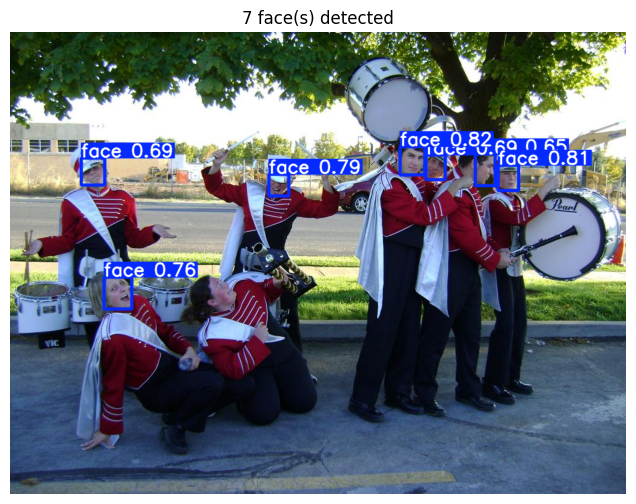

In [ ]:
# Find any image
img_dir = Path("../data/WIDER_FACE/wider_face/WIDER_val/images")
images = list(img_dir.rglob("*.jpg"))

if not images:
    raise FileNotFoundError("No images found!")

test_img = images[0]
print(f"Testing on: {test_img.name}")

# Detect
results = model(str(test_img), conf=0.3, verbose=False)
boxes = results[0].boxes

print(f"Detections: {len(boxes)}")
for i, box in enumerate(boxes[:3]):
    print(f"  Face {i+1}: conf={float(box.conf[0]):.3f}")

# Show
annotated = results[0].plot()
plt.figure(figsize=(10, 6))
plt.imshow(cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB))
plt.title(f"{len(boxes)} face(s) detected")
plt.axis('off')
plt.savefig("../results/test_single.png", dpi=150, bbox_inches='tight')
plt.show()

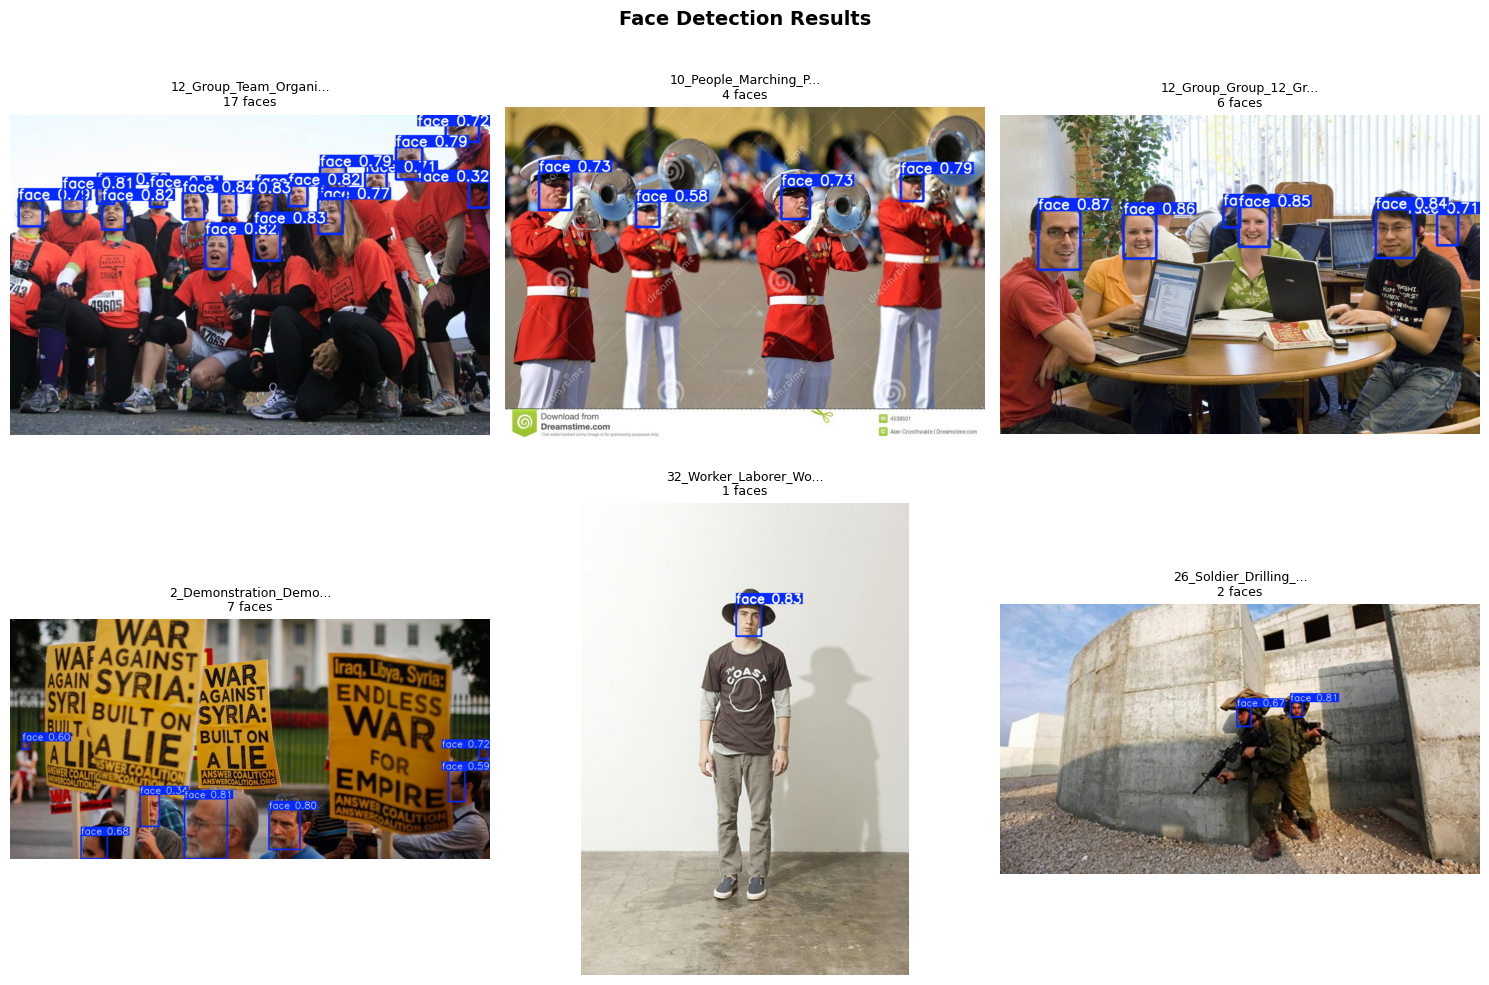

In [16]:
import random

# Pick 6 random images
sample = random.sample(images, min(6, len(images)))

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for idx, img_path in enumerate(sample):
    results = model(str(img_path), conf=0.3, verbose=False)
    annotated = results[0].plot()
    
    axes[idx].imshow(cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB))
    axes[idx].set_title(f"{img_path.name[:20]}...\n{len(results[0].boxes)} faces", fontsize=9)
    axes[idx].axis('off')

plt.suptitle("Face Detection Results", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig("../results/multiple_samples.png", dpi=150, bbox_inches='tight')
plt.show()

In [17]:
# Test on 30 images and collect metrics
test_images = random.sample(images, min(30, len(images)))

all_confidences = []
face_counts = []
inference_times = []

for img_path in test_images:
    start = time.time()
    results = model(str(img_path), conf=0.3, verbose=False)
    elapsed = time.time() - start
    
    inference_times.append(elapsed * 1000)  # ms
    face_counts.append(len(results[0].boxes))
    
    for box in results[0].boxes:
        all_confidences.append(float(box.conf[0]))

# Create metrics DataFrame
metrics_df = pd.DataFrame({
    'Metric': ['Images Tested', 'Total Faces', 'Avg Faces/Image', 
               'Avg Confidence', 'Min Confidence', 'Max Confidence', 'Avg Inference (ms)'],
    'Value': [
        len(test_images),
        sum(face_counts),
        f"{np.mean(face_counts):.2f}",
        f"{np.mean(all_confidences):.4f}" if all_confidences else "N/A",
        f"{np.min(all_confidences):.4f}" if all_confidences else "N/A",
        f"{np.max(all_confidences):.4f}" if all_confidences else "N/A",
        f"{np.mean(inference_times):.2f}"
    ]
})

print("="*50)
print("DETECTION METRICS")
print("="*50)
display(metrics_df)

metrics_df.to_csv("../results/detection_metrics.csv", index=False)
print(f"\n✅ Saved to: ../results/detection_metrics.csv")

DETECTION METRICS


,Metric,Value
0,Images Tested,30
1,Total Faces,256
2,Avg Faces/Image,8.53
3,Avg Confidence,0.6570
4,Min Confidence,0.3009
5,Max Confidence,0.8984
6,Avg Inference (ms),61.47



✅ Saved to: ../results/detection_metrics.csv


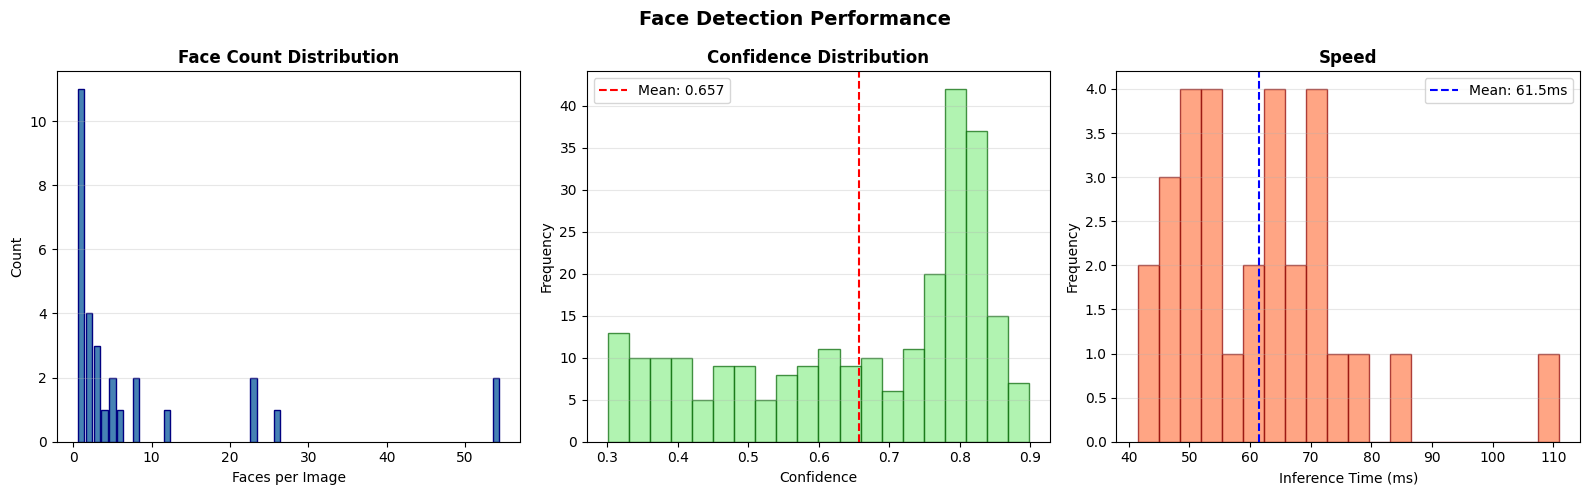

In [20]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Chart 1: Faces per image
unique, counts = np.unique(face_counts, return_counts=True)
axes[0].bar(unique, counts, color='steelblue', edgecolor='navy')
axes[0].set_xlabel('Faces per Image')
axes[0].set_ylabel('Count')
axes[0].set_title('Face Count Distribution', fontweight='bold')
axes[0].grid(axis='y', alpha=0.3)

# Chart 2: Confidence histogram
if all_confidences:
    axes[1].hist(all_confidences, bins=20, color='lightgreen', edgecolor='darkgreen', alpha=0.7)
    axes[1].axvline(np.mean(all_confidences), color='red', linestyle='--', label=f'Mean: {np.mean(all_confidences):.3f}')
    axes[1].set_xlabel('Confidence')
    axes[1].set_ylabel('Frequency')
    axes[1].set_title('Confidence Distribution', fontweight='bold')
    axes[1].legend()
    axes[1].grid(axis='y', alpha=0.3)

# Chart 3: Inference time
axes[2].hist(inference_times, bins=20, color='coral', edgecolor='darkred', alpha=0.7)
axes[2].axvline(np.mean(inference_times), color='blue', linestyle='--', label=f'Mean: {np.mean(inference_times):.1f}ms')
axes[2].set_xlabel('Inference Time (ms)')
axes[2].set_ylabel('Frequency')
axes[2].set_title('Speed', fontweight='bold')
axes[2].legend()
axes[2].grid(axis='y', alpha=0.3)

plt.suptitle('Face Detection Performance', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig("../img/performance_charts.png", dpi=150, bbox_inches='tight')
plt.show()